In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
import os
for dirname, _, filenames in os.walk('H:/Datasets/ecommerce/ecommerce_sale'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

H:/Datasets/ecommerce/ecommerce_sale\Amazon_Sale_Report.csv
H:/Datasets/ecommerce/ecommerce_sale\Cloud_Warehouse_Compersion_Chart.csv
H:/Datasets/ecommerce/ecommerce_sale\Expense_IIGF.csv
H:/Datasets/ecommerce/ecommerce_sale\International_sale_Report.csv
H:/Datasets/ecommerce/ecommerce_sale\May-2022.csv
H:/Datasets/ecommerce/ecommerce_sale\PLMarch2021.csv
H:/Datasets/ecommerce/ecommerce_sale\Sale_Report.csv


In [3]:
amazon_sale_report_df = pd.read_csv("H:/Datasets/ecommerce/ecommerce_sale/Amazon Sale Report.csv", low_memory=False)
cloud_warehouse_compersion_chart_df = pd.read_csv("H:/Datasets/ecommerce/ecommerce_sale/Cloud Warehouse Compersion Chart.csv", low_memory=False)
may_2022_df = pd.read_csv("H:/Datasets/ecommerce/ecommerce_sale/May-2022.csv", low_memory=False)
pl_march_2021_df = pd.read_csv("H:/Datasets/ecommerce/ecommerce_sale/PLMarch2021.csv", low_memory=False)
international_sale_report_df = pd.read_csv("H:/Datasets/ecommerce/ecommerce_sale/International sale Report.csv", low_memory=False)
expense_iigf_df = pd.read_csv("H:/Datasets/ecommerce/ecommerce_sale/Expense IIGF.csv", low_memory=False)
sale_report_df = pd.read_csv("H:/Datasets/ecommerce/ecommerce_sale/Sale Report.csv", low_memory=False)

FileNotFoundError: [Errno 2] No such file or directory: 'H:/Datasets/ecommerce/ecommerce_sale/Amazon Sale Report.csv'

In [4]:
amazon_sale_report_df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [5]:
amazon_sale_report_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [6]:
amazon_sale_report_df['Date']

0         04-30-22
1         04-30-22
2         04-30-22
3         04-30-22
4         04-30-22
            ...   
128970    05-31-22
128971    05-31-22
128972    05-31-22
128973    05-31-22
128974    05-31-22
Name: Date, Length: 128975, dtype: object

In [7]:
import datetime

amazon_sale_report_df['year_month'] = pd.to_datetime(amazon_sale_report_df['Date']).dt.to_period('M')

C:\Users\Maruata\AppData\Local\Temp\ipykernel_532\2311073530.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  amazon_sale_report_df['year_month'] = pd.to_datetime(amazon_sale_report_df['Date']).dt.to_period('M')


In [8]:
amazon_sale_report_df['year_month']

0         2022-04
1         2022-04
2         2022-04
3         2022-04
4         2022-04
           ...   
128970    2022-05
128971    2022-05
128972    2022-05
128973    2022-05
128974    2022-05
Name: year_month, Length: 128975, dtype: period[M]

In [9]:
#calculate amount based on month
monthly_sales = amazon_sale_report_df.groupby('year_month')['Amount'].sum().reset_index()

In [10]:
monthly_sales

,year_month,Amount
0,2022-03,101683.85
1,2022-04,28838708.32
2,2022-05,26226476.75
3,2022-06,23425809.38


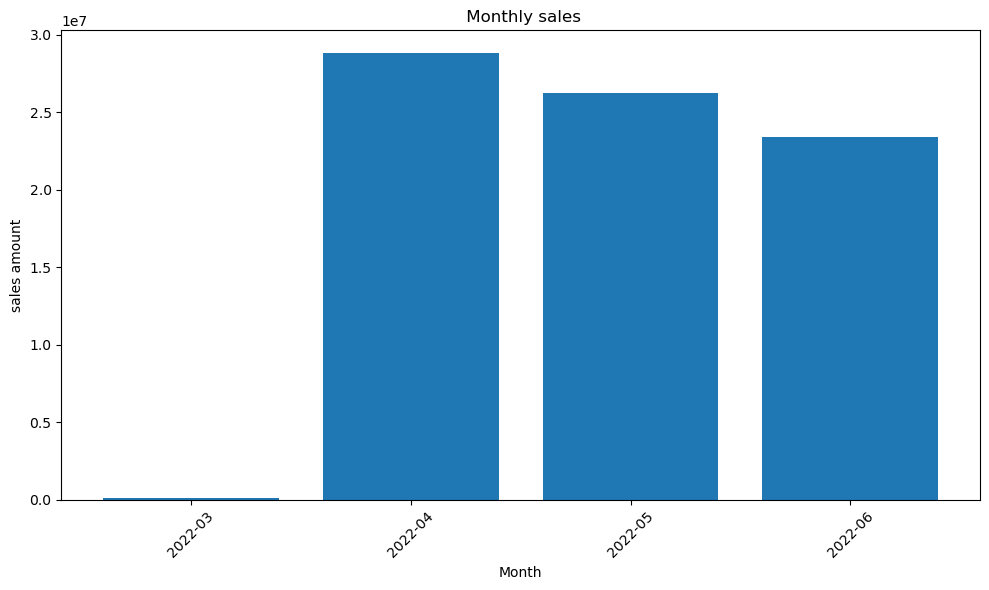

In [11]:
#plot the bar chart
plt.figure(figsize= (10,6))
plt.bar(monthly_sales['year_month'].dt.strftime('%Y-%m'), monthly_sales['Amount'])

#add labels to title
plt.xlabel('Month')
plt.ylabel('sales amount')
plt.title(' Monthly sales')


#show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
amazon_sale_report_df['Date'] = pd.to_datetime(amazon_sale_report_df['Date'], errors='coerce') #convert Date data to datetime



C:\Users\Maruata\AppData\Local\Temp\ipykernel_532\3598525321.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  amazon_sale_report_df['Date'] = pd.to_datetime(amazon_sale_report_df['Date'], errors='coerce') #convert Date data to datetime


In [13]:
amazon_sale_report_df['Date']

0        2022-04-30
1        2022-04-30
2        2022-04-30
3        2022-04-30
4        2022-04-30
            ...    
128970   2022-05-31
128971   2022-05-31
128972   2022-05-31
128973   2022-05-31
128974   2022-05-31
Name: Date, Length: 128975, dtype: datetime64[ns]

In [14]:
totalSum = amazon_sale_report_df.groupby([
                       pd.to_datetime(amazon_sale_report_df['Date']).dt.month,
                       'Category']).agg({'Amount': sum})
totalSum

C:\Users\Maruata\AppData\Local\Temp\ipykernel_532\359250759.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  'Category']).agg({'Amount': sum})


Amount
Date Category                  
3    Blouse              280.00
     Ethnic Dress       1099.00
     Set               53884.00
     Top                4511.00
     Western Dress      7653.28
     kurta             34256.57
4    Blouse           195583.21
     Bottom            63308.45
     Ethnic Dress     250666.65
     Saree             55655.24
     Set            15506675.56
     Top             1821893.22
     Western Dress   2927780.51
     kurta           8017145.48
5    Blouse           159794.68
     Bottom            50866.57
     Ethnic Dress     293092.34
     Saree             41536.62
     Set            12643698.35
     Top             1995607.16
     Western Dress   4381304.41
     kurta           6660576.62
6    Blouse           102750.29
     Bottom            36492.96
     Dupatta             915.00
     Ethnic Dress     246359.67
     Saree             26741.90
     Set            10999866.12
     Top             1525780.92
     Western Dress   3899334.49
     kurta           6587568.03

In [15]:
category_df = totalSum.pivot_table(index='Date', columns='Category', values='Amount', aggfunc='sum')
category_df

Category,Blouse,Bottom,Dupatta,Ethnic Dress,Saree,Set,Top,Western Dress,kurta
Date,,,,,,,,,
3,280.00,NaN,NaN,1099.00,NaN,53884.00,4511.00,7653.28,34256.57
4,195583.21,63308.45,NaN,250666.65,55655.24,15506675.56,1821893.22,2927780.51,8017145.48
5,159794.68,50866.57,NaN,293092.34,41536.62,12643698.35,1995607.16,4381304.41,6660576.62
6,102750.29,36492.96,915.0,246359.67,26741.90,10999866.12,1525780.92,3899334.49,6587568.03


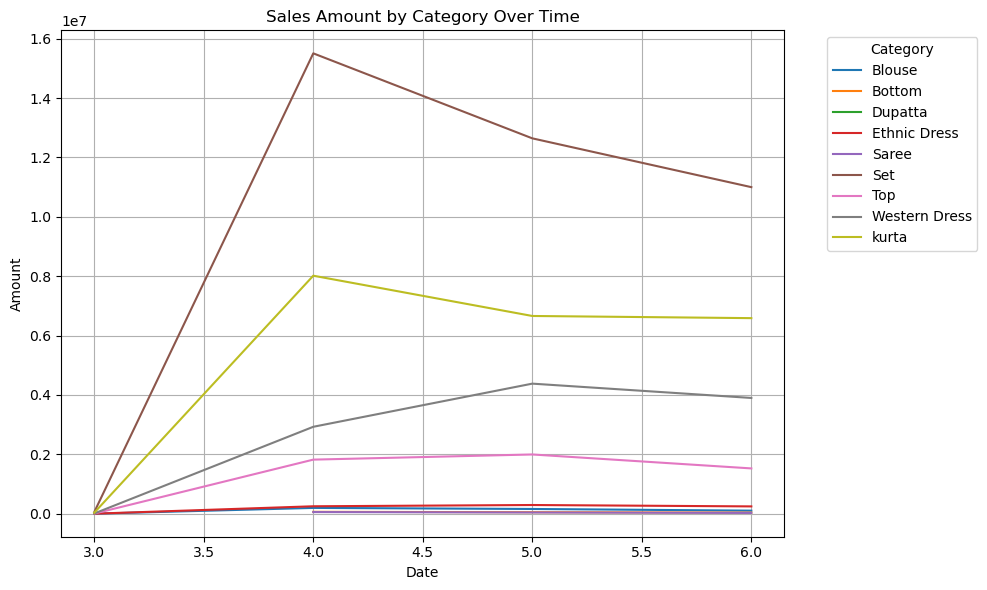

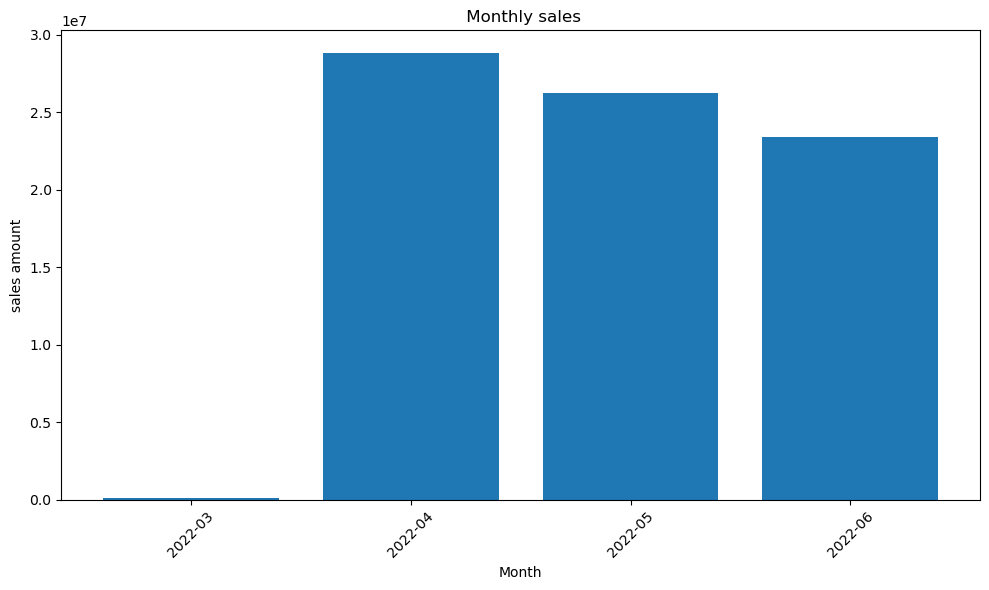

In [16]:
# Plot the data
category_df.plot(kind='line', figsize=(10, 6))
# Customize the plot
plt.title('Sales Amount by Category Over Time')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


#plot the bar chart
plt.figure(figsize= (10,6))
plt.bar(monthly_sales['year_month'].dt.strftime('%Y-%m'), monthly_sales['Amount'])

#add labels to title
plt.xlabel('Month')
plt.ylabel('sales amount')
plt.title(' Monthly sales')


#show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [17]:
amazon_sale_report_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               128975 non-null  int64         
 1   Order ID            128975 non-null  object        
 2   Date                128975 non-null  datetime64[ns]
 3   Status              128975 non-null  object        
 4   Fulfilment          128975 non-null  object        
 5   Sales Channel       128975 non-null  object        
 6   ship-service-level  128975 non-null  object        
 7   Style               128975 non-null  object        
 8   SKU                 128975 non-null  object        
 9   Category            128975 non-null  object        
 10  Size                128975 non-null  object        
 11  ASIN                128975 non-null  object        
 12  Courier Status      122103 non-null  object        
 13  Qty                 128975 no

In [18]:
print(amazon_sale_report_df.columns)

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22', 'year_month'],
      dtype='object')


In [19]:
amazon_sale_report_df['ship-city'].value_counts()

ship-city
BENGALURU                                      11217
HYDERABAD                                       8074
MUMBAI                                          6126
NEW DELHI                                       5795
CHENNAI                                         5421
                                               ...  
Khandavalli, peravali mandal, west godavari        1
Bhayander west                                     1
JAKHALMANDI                                        1
Arariya                                            1
Halol                                              1
Name: count, Length: 8955, dtype: int64

In [20]:
#calculate amount based on each city
sales_city = amazon_sale_report_df.groupby('ship-city')['Amount'].sum().reset_index()
sales_city

,ship-city,Amount
0,(Chikmagalur disterict). (N.R pur thaluku),389.0
1,"(Via Cuncolim)Quepem,South Goa",1163.0
2,",HYDERABAD",563.0
3,",raibarely road faizabad (Ayodhya)",1122.0
4,..katra,641.0
...,...,...
8950,yavatmal,735.0
8951,yazali,487.0
8952,yellapur,824.0
8953,zirakpur,852.0


In [21]:
#taking postal_data in seperate df for simplification
amazon_sale_report_df['ship-postal-code'] = amazon_sale_report_df['ship-postal-code'].fillna(0).astype(int)
amazon_sale_report_df['ship-postal-code'].value_counts()
postal_df = amazon_sale_report_df['ship-postal-code']
postal_df

0         400081
1         560085
2         410210
3         605008
4         600073
           ...  
128970    500013
128971    122004
128972    500049
128973    389350
128974    492014
Name: ship-postal-code, Length: 128975, dtype: int32

In [22]:
postal_df = pd.DataFrame(postal_df)
postal_df = postal_df[~postal_df['ship-postal-code'].astype(str).str[:3].eq('744')]# removing andaman postalcode as a outlier 
postal_df = postal_df[~postal_df['ship-postal-code'].astype(str).str[:3].eq('682')]# removing  Lakshadweep postalcode as a outlier 

#postal_df

In [23]:
#keep first duplicate value
postal_df = postal_df.drop_duplicates(subset=['ship-postal-code'])
#postal_df

In [24]:
import pgeocode

In [25]:
#initialize pgeocode with country for India
geocode = pgeocode.Nominatim('IN')

In [26]:
#function to get the coordinates
def get_coordinates(postal_code):
    try:
        results = geocode.query_postal_code(postal_code)
        return pd.Series([results.latitude , results.longitude], index = ['Latitude','Longitude'])
    except Exception as e:
        print(f"Error for postal code {postal_code} : {e}")
        return pd.Series([None, None], index = ['Latitude', 'Longitude'])

In [27]:
postal_df[['Latitude', 'Longitude']] = postal_df['ship-postal-code'].apply(get_coordinates)

In [28]:
postal_df

,ship-postal-code,Latitude,Longitude
0,400081,18.980800,72.833800
1,560085,13.225700,77.575000
2,410210,19.049800,73.070200
3,605008,11.876800,79.810700
4,600073,12.844667,80.095767
...,...,...,...
128384,521322,16.380400,80.978300
128527,827302,23.603517,85.974542
128542,609603,10.974200,79.758500
128557,851205,25.515856,86.579889


In [29]:
from shapely.geometry import Point
import geopandas as gpd

In [30]:
#create point geometry
geometry = [Point(xy) for xy in zip(postal_df['Longitude'], postal_df['Latitude'])]

#convert to GeoDataframe
gdf = gpd.GeoDataFrame(postal_df , geometry = geometry)

<Axes: >

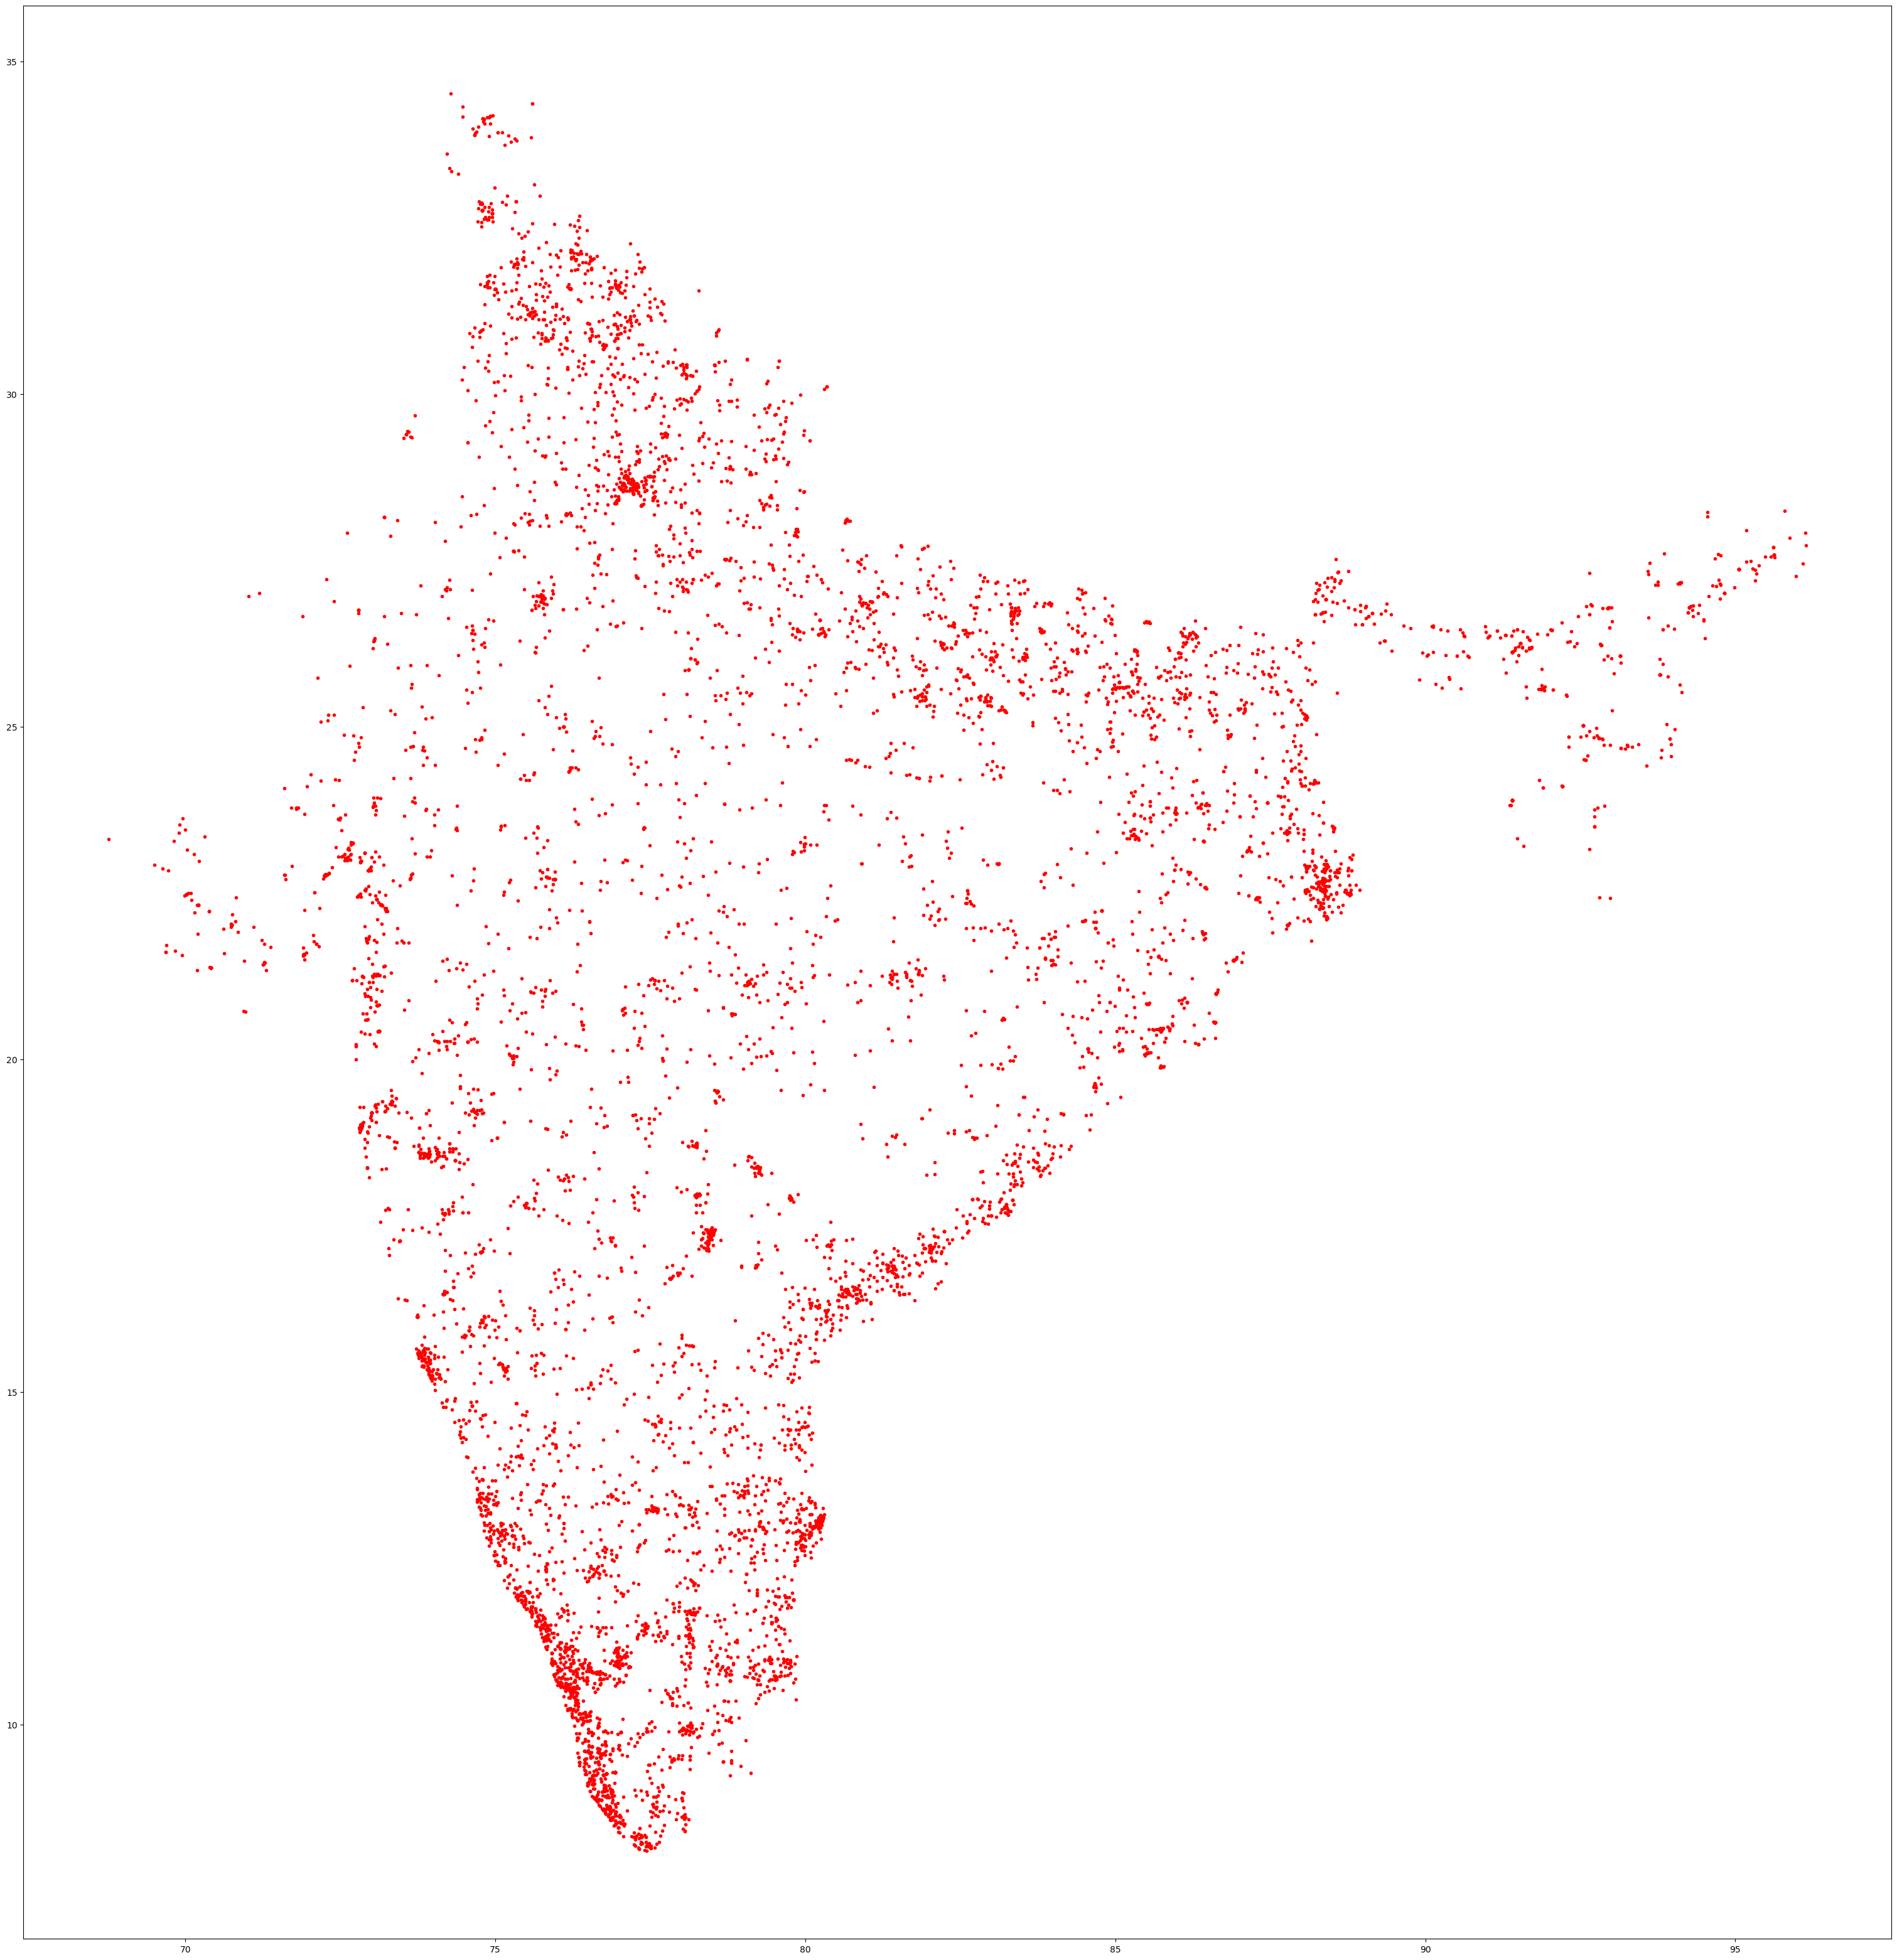

In [31]:
#https://www.agsrt.com/post/visualizing-capital-cities-in-india-with-python-from-csvfile-agsrt-gisblogs
gdf = gdf.set_crs(epsg = 4326)

gdf.plot(marker='.', color = 'red', figsize=(40,40))

In [32]:
#ax = gdf.plot(marker='.', color = 'red', figsize=(12,8))
#ctx.add_basemap(ax)

In [33]:
from sklearn.cluster import KMeans

In [34]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 9383 entries, 0 to 128944
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   ship-postal-code  9383 non-null   int32   
 1   Latitude          9193 non-null   float64 
 2   Longitude         9193 non-null   float64 
 3   geometry          9383 non-null   geometry
dtypes: float64(2), geometry(1), int32(1)
memory usage: 329.9 KB


In [35]:
#dropping null value
gdf_clean = gdf.dropna(subset = ['Latitude','Longitude'])

In [36]:
k= 50 #number of cluster
initial_centroids = gdf_clean[['Latitude','Longitude']].iloc[:k].values
#initial_centroids

In [37]:
#seperating points for clustering
coords = gdf_clean[['Latitude', 'Longitude']].values
#coords

In [38]:
kmeans = KMeans(n_clusters=k ,init = initial_centroids, n_init = 1 , random_state=42) #adjust number of store here
gdf_clean['cluster'] = kmeans.fit_predict(coords)

C:\Users\Maruata\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Maruata\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Maruata\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Maruata\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Maruata\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi

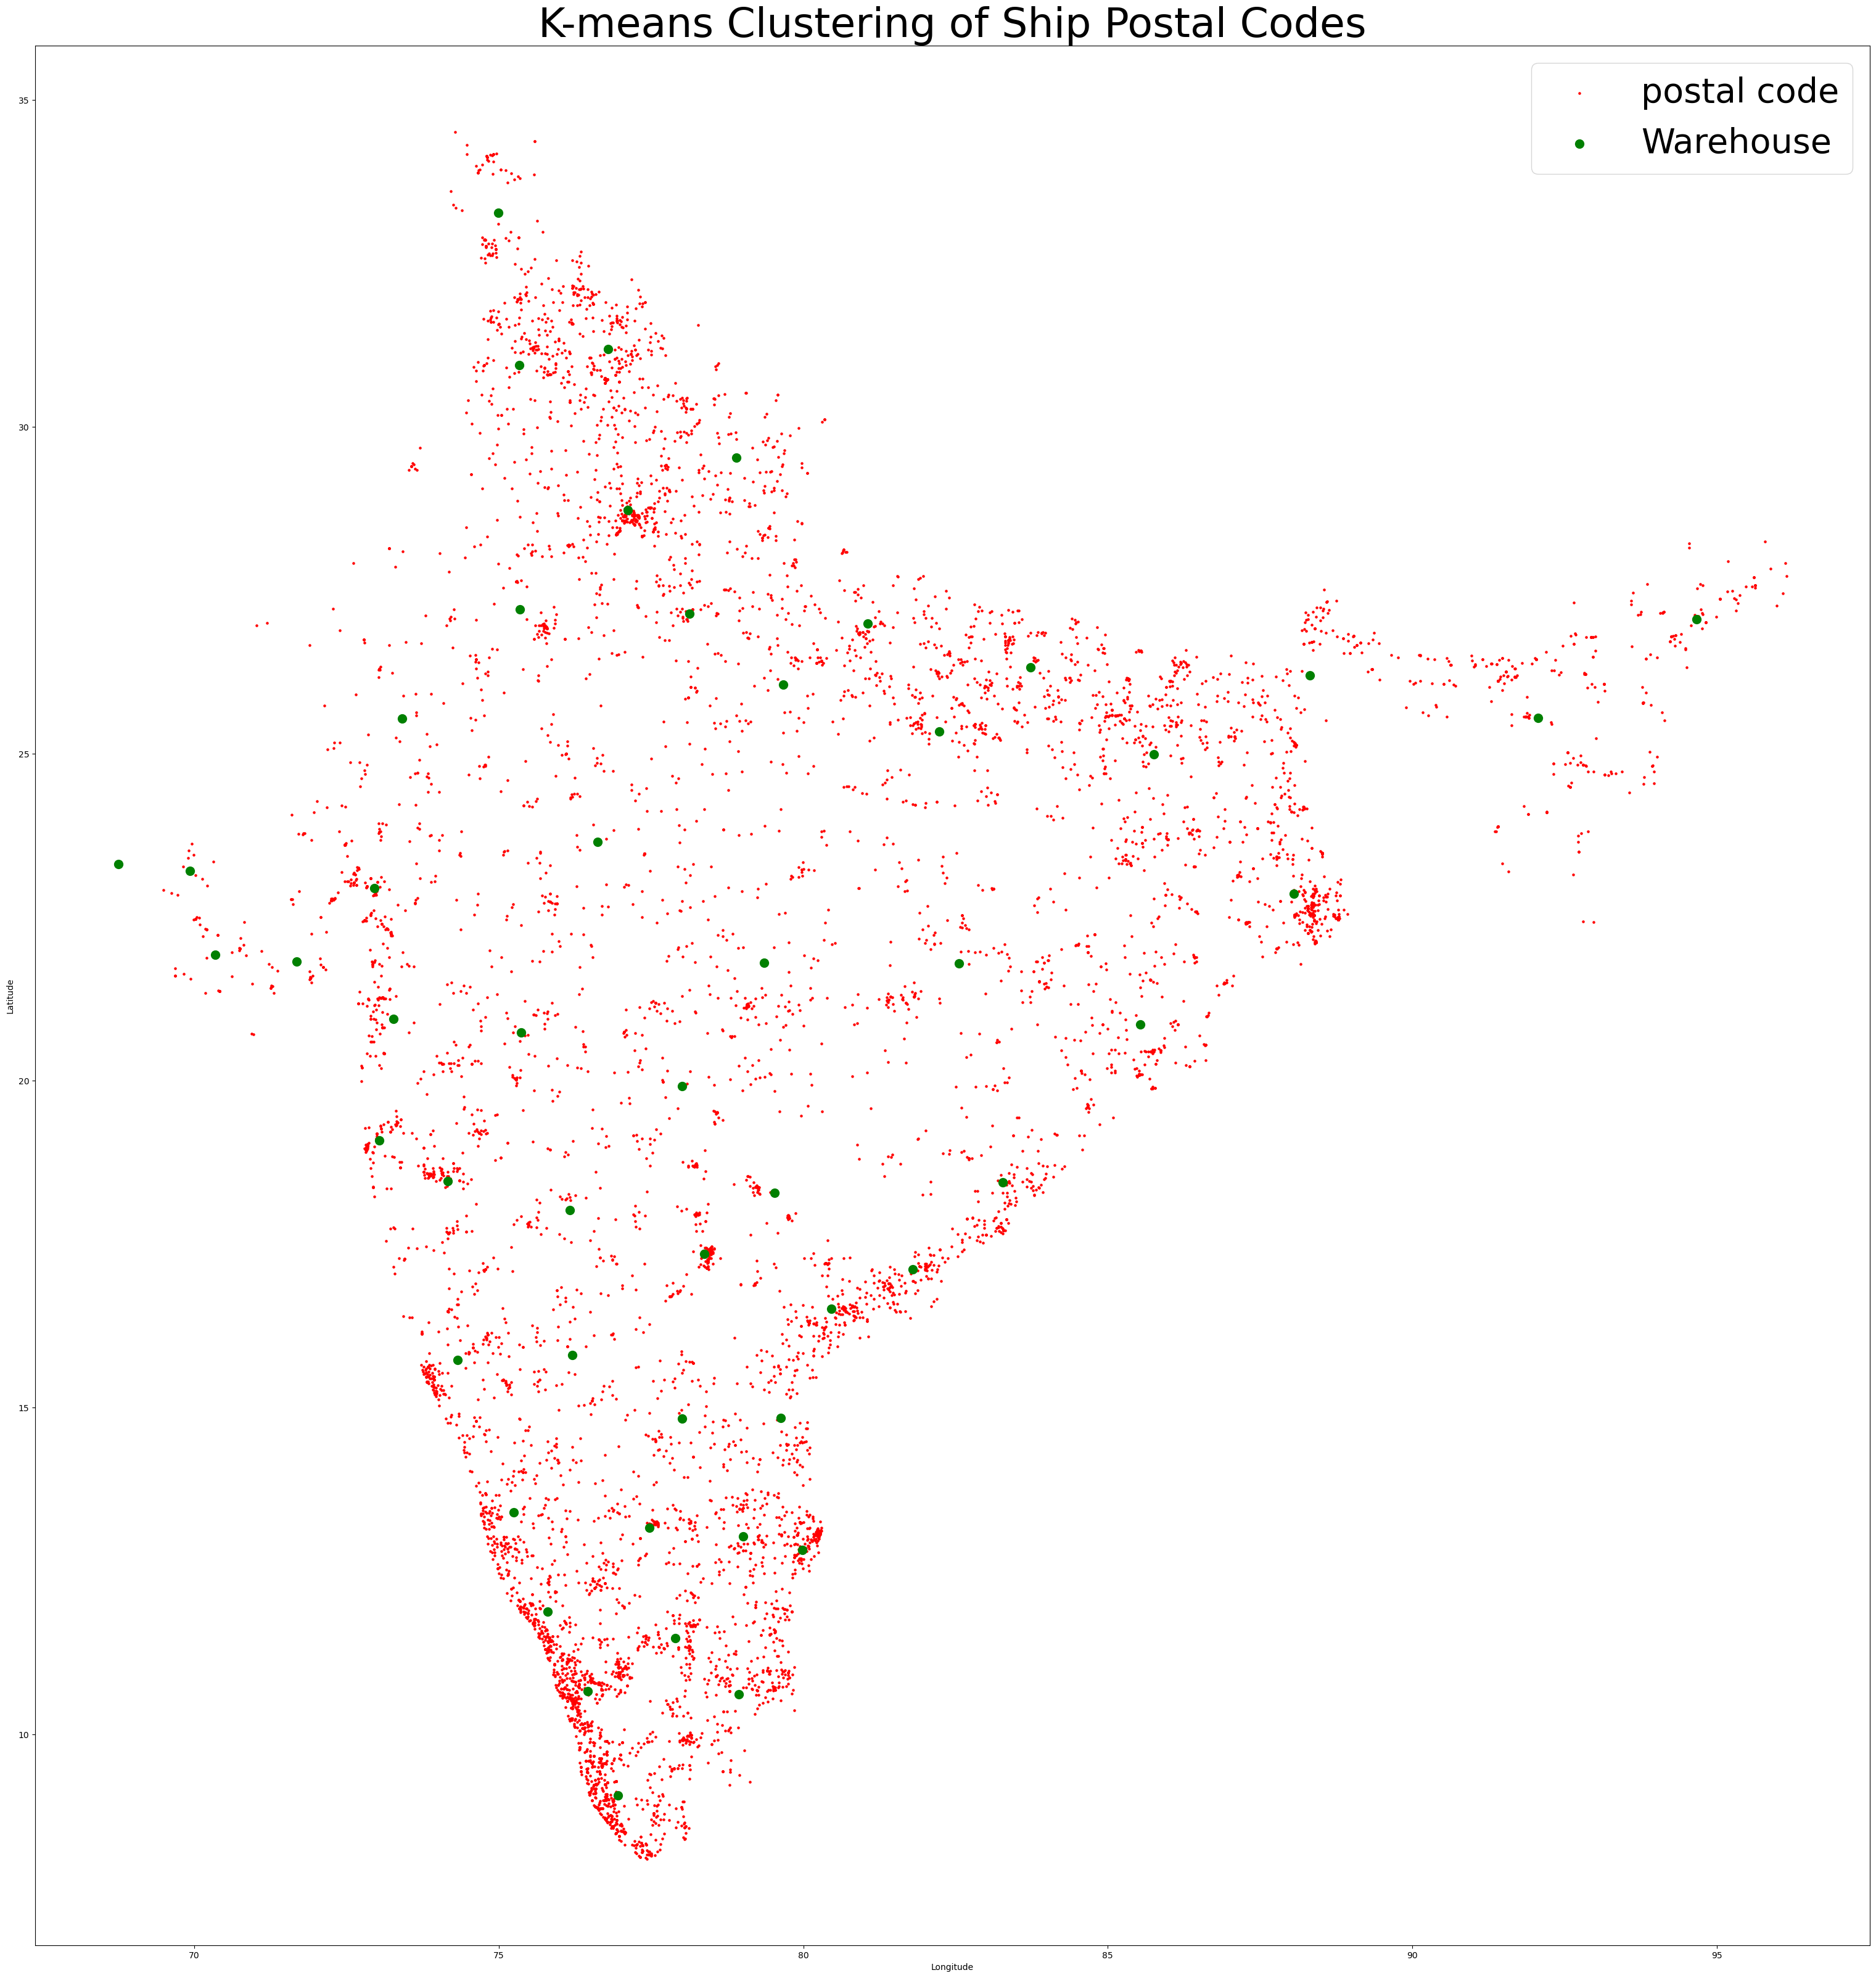

In [39]:
#plotting

fig, ax = plt.subplots(figsize=(40,40))
plt.rcParams.update({'font.size': 40})

#plot original datapoints in red
gdf_clean.plot(ax=ax, color = 'red' , markersize = 5, label = 'postal code')

#plot warehouse in green
warehouses = kmeans.cluster_centers_
ax.scatter(warehouses[:, 1], warehouses[:, 0], c='green', s=100, marker='o', label='Warehouse')


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-means Clustering of Ship Postal Codes')
plt.legend()
plt.show()

In [40]:
amazon_sale_report_df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22,year_month
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,647.62,MUMBAI,MAHARASHTRA,400081,IN,NaN,False,Easy Ship,NaN,2022-04
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,406.00,BENGALURU,KARNATAKA,560085,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,2022-04
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN,2022-04
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,NaN,False,Easy Ship,NaN,2022-04
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,574.00,CHENNAI,TAMIL NADU,600073,IN,NaN,False,NaN,NaN,2022-04


In [41]:
amazon_sale_report_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               128975 non-null  int64         
 1   Order ID            128975 non-null  object        
 2   Date                128975 non-null  datetime64[ns]
 3   Status              128975 non-null  object        
 4   Fulfilment          128975 non-null  object        
 5   Sales Channel       128975 non-null  object        
 6   ship-service-level  128975 non-null  object        
 7   Style               128975 non-null  object        
 8   SKU                 128975 non-null  object        
 9   Category            128975 non-null  object        
 10  Size                128975 non-null  object        
 11  ASIN                128975 non-null  object        
 12  Courier Status      122103 non-null  object        
 13  Qty                 128975 no

In [42]:
set_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'Set']
kurta_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'kurta']
Western_Dress_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'Western Dress']
Top_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'Top']
Ethnic_Dress_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'Ethnic Dress']
Bottom_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'Bottom']
Saree_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'Saree']
Blouse_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'Blouse']
Dupatta_df = amazon_sale_report_df[amazon_sale_report_df.Category == 'Dupatta']

In [43]:
#keep first duplicate value
#postal_df = postal_df.drop_duplicates(subset=['ship-postal-code'])
#postal_df

set_df = set_df.drop_duplicates(subset=['ship-postal-code'])
#set_df

#postal_df[['Latitude', 'Longitude']] = postal_df['ship-postal-code'].apply(get_coordinates)
set_df[['Latitude', 'Longitude']] = set_df['ship-postal-code'].apply(get_coordinates)


In [44]:
#create point geometry
geometry_set = [Point(xy) for xy in zip(set_df['Longitude'], set_df['Latitude'])]

#convert to GeoDataframe
gdf_set = gpd.GeoDataFrame(set_df , geometry = geometry_set)

gdf_set = gdf.set_crs(epsg = 4326)

#gdf_set.plot(marker='.', color = 'orange', figsize=(10,8))

In [45]:
kurta_df = set_df.drop_duplicates(subset=['ship-postal-code'])
#set_df

#postal_df[['Latitude', 'Longitude']] = postal_df['ship-postal-code'].apply(get_coordinates)
kurta_df[['Latitude', 'Longitude']] = set_df['ship-postal-code'].apply(get_coordinates)

In [46]:
#create point geometry
geometry_kurta = [Point(xy) for xy in zip(kurta_df['Longitude'], kurta_df['Latitude'])]

#convert to GeoDataframe
gdf_kurta = gpd.GeoDataFrame(kurta_df , geometry = geometry_kurta)

gdf_kurta = gdf_kurta.set_crs(epsg = 4326)

#gdf_kurta.plot(marker='.', color = 'green', figsize=(10,8))

In [47]:
Dupatta_df = Dupatta_df.drop_duplicates(subset=['ship-postal-code'])
#set_df

#postal_df[['Latitude', 'Longitude']] = postal_df['ship-postal-code'].apply(get_coordinates)
Dupatta_df[['Latitude', 'Longitude']] = Dupatta_df['ship-postal-code'].apply(get_coordinates)

In [48]:
#create point geometry
geometry_Dupatta = [Point(xy) for xy in zip(Dupatta_df['Longitude'], Dupatta_df['Latitude'])]

#convert to GeoDataframe
gdf_Dupatta = gpd.GeoDataFrame(Dupatta_df, geometry = geometry_Dupatta)

gdf_Dupatta = gdf_Dupatta.set_crs(epsg = 4326)

#gdf_Dupatta.plot(marker='.', color = 'green', figsize=(10,8))

In [49]:
Western_Dress_df =Western_Dress_df.drop_duplicates(subset=['ship-postal-code'])
#set_df

#postal_df[['Latitude', 'Longitude']] = postal_df['ship-postal-code'].apply(get_coordinates)
Western_Dress_df[['Latitude', 'Longitude']] = Western_Dress_df['ship-postal-code'].apply(get_coordinates)


#create point geometry
geometry_Western_Dress_df = [Point(xy) for xy in zip(Western_Dress_df['Longitude'], Western_Dress_df['Latitude'])]

#convert to GeoDataframe
gdf_Western_Dress_df = gpd.GeoDataFrame(Western_Dress_df, geometry = geometry_Western_Dress_df)

gdf_Western_Dress_df = gdf_Western_Dress_df.set_crs(epsg = 4326)


In [50]:
Saree_df =Saree_df.drop_duplicates(subset=['ship-postal-code'])
#set_df

#postal_df[['Latitude', 'Longitude']] = postal_df['ship-postal-code'].apply(get_coordinates)
Saree_df[['Latitude', 'Longitude']] = Saree_df['ship-postal-code'].apply(get_coordinates)


#create point geometry
geometry_Saree_df = [Point(xy) for xy in zip(Saree_df['Longitude'], Saree_df['Latitude'])]

#convert to GeoDataframe
gdf_Saree_df = gpd.GeoDataFrame(Saree_df, geometry = geometry_Saree_df)

gdf_Saree_df = gdf_Saree_df.set_crs(epsg = 4326)

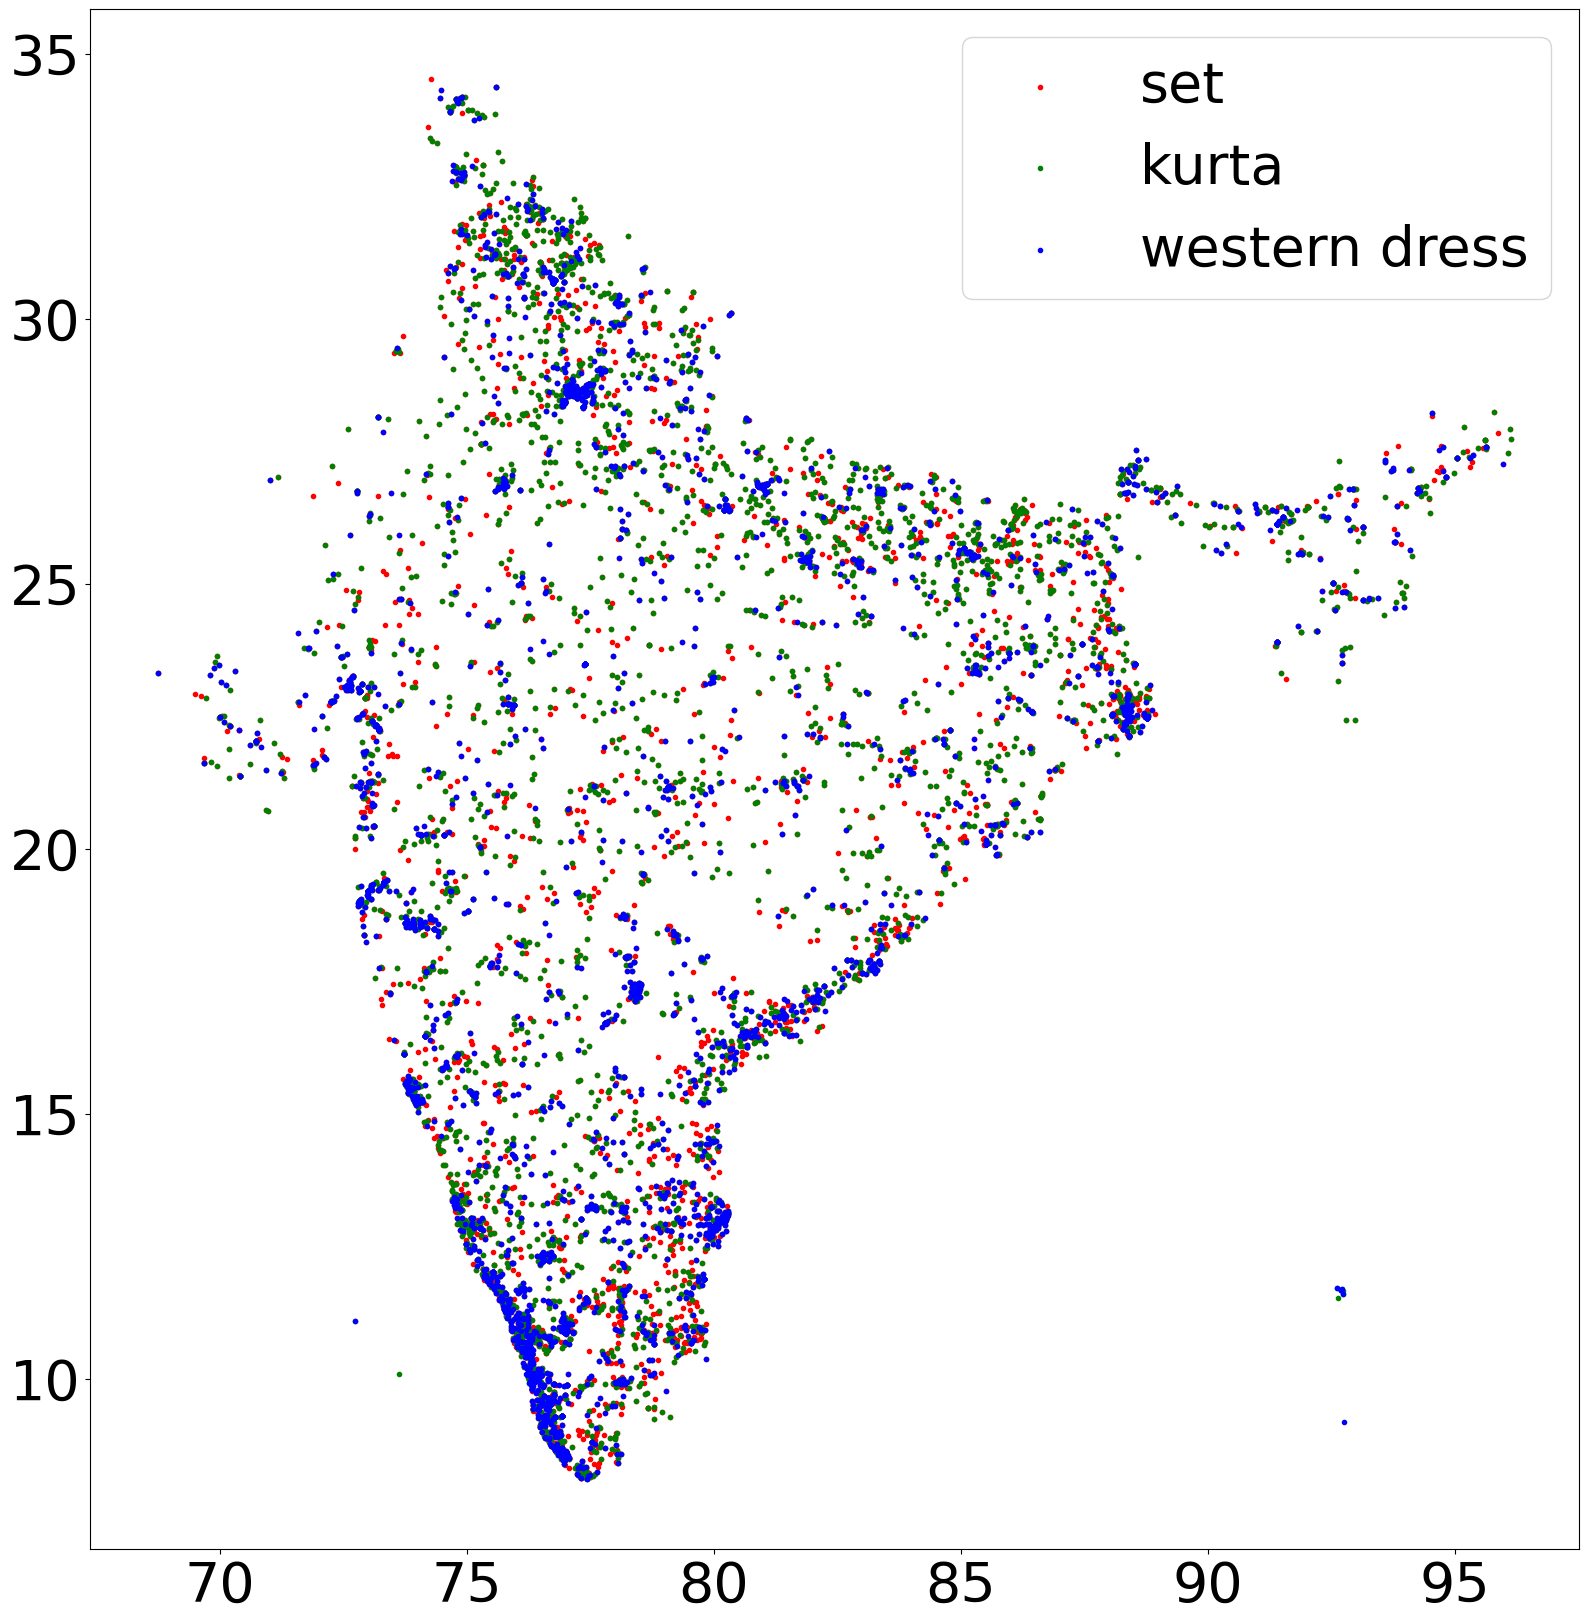

In [51]:
fig , ax = plt.subplots(figsize=(20,20))

gdf_set.plot(ax=ax ,marker='.', color = 'red', label = "set")

gdf_kurta.plot(ax = ax ,marker='.', color = 'green', label = "kurta")

gdf_Western_Dress_df.plot(ax =ax ,marker='.', color = 'blue', label = "western dress")

ax.legend()

plt.show()